# Sentiment Analysis on Coronavirus Tweets

This is a natural language processing project in which I build multiple RNNs and LSTMs to predict the sentiments of tweets related to the coronavirus.

Dataset: https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import gensim
from gensim.utils import simple_preprocess
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from torchmetrics import MetricCollection, Accuracy, Precision, Recall, F1Score
from tabulate import tabulate

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hongngchiu/glove-2024-wikigiga-50d/wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt
/kaggle/input/datasets/sugataghosh/google-word2vec/GoogleNews-vectors-negative300.bin
/kaggle/input/datasets/datatattle/covid-19-nlp-text-classification/Corona_NLP_test.csv
/kaggle/input/datasets/datatattle/covid-19-nlp-text-classification/Corona_NLP_train.csv


### Set hyperparameters

In [2]:
optimizer = "Adam"
learning_rate = 0.001
hidden_size = 256
num_layers = 1
dropout = 0
num_labels = 5
custom_embedding_size = 256
batch_size = 64
epochs = 10

### Load and inspect dataset

The dataset has 5 different features. For simplicity, I only used OriginalTweet, which contains the main text of the tweet. The Sentiment label can take on 5 different values. I used one-hot encoding for these values.

I used the gensim library to split the tweets into words, remove any numbers or special characters, and convert everything to lowercase.

In [3]:
df_train = pd.read_csv(
    "/kaggle/input/datasets/datatattle/covid-19-nlp-text-classification/Corona_NLP_train.csv",
    encoding="ISO-8859-1"
)
df_test = pd.read_csv(
    "/kaggle/input/datasets/datatattle/covid-19-nlp-text-classification/Corona_NLP_test.csv",
    encoding="ISO-8859-1"
)

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       3798 non-null   int64 
 1   ScreenName     3798 non-null   int64 
 2   Location       2964 non-null   object
 3   TweetAt        3798 non-null   object
 4   OriginalTweet  3798 non-null   object
 5   Sentiment      3798 non-null   object
dtypes: int64(2), object(4)
memory usage: 178.2+ KB


In [6]:
df_train.Sentiment.value_counts()

Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64

In [7]:
df_train.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [8]:
one_hot = OneHotEncoder(sparse_output=False)
X_train = df_train.OriginalTweet.apply(simple_preprocess).to_numpy()
y_train = one_hot.fit_transform(df_train[["Sentiment"]])
X_test = df_test.OriginalTweet.apply(simple_preprocess).to_numpy()
y_test = one_hot.transform(df_test[["Sentiment"]])

### Set up word embeddings

I converted each word in each tweet to an embedding vector. I tested three different approaches:
1. Glove embeddings (1.2M-word vocabulary, 50 dimensions)
2. Word2vec embeddings (3M-word vocabulary, 300 dimensions)
3. Custom embedding layer (vocabulary drawn from training set, experimented with various dimensions from 16-256)

In [9]:
vocabulary = {word for sentence in X_train for word in sentence}
ordinal_encoder = {word: index for index, word in enumerate(vocabulary, start=1)}
vocab_size = len(vocabulary) + 1

# Loading word2vec and glove takes a long time, so don't reload them if they're already loaded
try:
    word2vec
except NameError:
    print("Loading word2vec...")
    word2vec_path = (
        "/kaggle"
        "/input"
        "/datasets"
        "/sugataghosh"
        "/google-word2vec"
        "/GoogleNews-vectors-negative300.bin"
    )
    word2vec = gensim.models.KeyedVectors.load_word2vec_format(word2vec_path, binary=True)
    print("Done loading word2vec.")

try:
    glove
except NameError:
    print("Loading glove...")
    glove_path = (
        "/kaggle"
        "/input"
        "/datasets"
        "/hongngchiu"
        "/glove-2024-wikigiga-50d"
        "/wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt"
    )
    glove = gensim.models.KeyedVectors.load_word2vec_format(glove_path, no_header=True)    
    print("Done loading glove.")

# Utility function for converting a word to an embedding
def get_embedding(word, embedding_type):
    if embedding_type == "custom":
        return ordinal_encoder[word] if word in ordinal_encoder else 0
    elif embedding_type == "word2vec":
        return word2vec[word] if word in word2vec else np.zeros(word2vec.vector_size)
    elif embedding_type == "glove":
        return glove[word] if word in glove else np.zeros(glove.vector_size)

Loading word2vec...
Done loading word2vec.
Loading glove...
Done loading glove.


#### Sample word embeddings

In [10]:
glove["dog"]

array([-0.882649, -0.441152,  0.045452, -0.74172 ,  0.568266,  0.358065,
        0.547057,  0.933872,  0.406013, -1.056753, -0.866654, -0.062371,
        0.427392,  0.541922, -0.86395 ,  0.605139, -0.438495, -0.728655,
        0.114824,  0.114709, -1.066622,  0.564354, -0.157254, -0.503675,
       -0.921841, -0.380373, -0.642852, -0.144314,  0.455408,  0.150176,
       -1.388725, -0.930925, -0.231992, -0.123769, -0.141568,  1.007351,
       -0.357805,  3.211342,  0.043015, -0.724083,  0.514256,  0.432809,
       -0.183939, -0.013507, -0.351845,  0.138201,  0.100585,  0.522738,
        0.17947 ,  1.109375], dtype=float32)

In [11]:
word2vec["dog"]

array([ 5.12695312e-02, -2.23388672e-02, -1.72851562e-01,  1.61132812e-01,
       -8.44726562e-02,  5.73730469e-02,  5.85937500e-02, -8.25195312e-02,
       -1.53808594e-02, -6.34765625e-02,  1.79687500e-01, -4.23828125e-01,
       -2.25830078e-02, -1.66015625e-01, -2.51464844e-02,  1.07421875e-01,
       -1.99218750e-01,  1.59179688e-01, -1.87500000e-01, -1.20117188e-01,
        1.55273438e-01, -9.91210938e-02,  1.42578125e-01, -1.64062500e-01,
       -8.93554688e-02,  2.00195312e-01, -1.49414062e-01,  3.20312500e-01,
        3.28125000e-01,  2.44140625e-02, -9.71679688e-02, -8.20312500e-02,
       -3.63769531e-02, -8.59375000e-02, -9.86328125e-02,  7.78198242e-03,
       -1.34277344e-02,  5.27343750e-02,  1.48437500e-01,  3.33984375e-01,
        1.66015625e-02, -2.12890625e-01, -1.50756836e-02,  5.24902344e-02,
       -1.07421875e-01, -8.88671875e-02,  2.49023438e-01, -7.03125000e-02,
       -1.59912109e-02,  7.56835938e-02, -7.03125000e-02,  1.19140625e-01,
        2.29492188e-01,  

### Create model and dataset classes

In [12]:
# RNN with built-in embeddings
class CustomRNN_Embeddings(nn.Module):
    def __init__(self, hidden_size, vocab_size, embedding_dim, output_size, model_type):
        super().__init__()
        self.model_type = model_type
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if self.model_type == "RNN":
            self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout)
        elif self.model_type == "LSTM":
            self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        unpacked_x, unpacked_len_x = pad_packed_sequence(x)
        embeddings = self.embedding(unpacked_x)
        packed_embeddings = pack_padded_sequence(embeddings, unpacked_len_x, enforce_sorted=False)
        if self.model_type == "RNN":
            out, h = self.rnn(packed_embeddings)
        elif self.model_type == "LSTM":
            out, (h, c) = self.lstm(packed_embeddings)
        y_pred = self.linear(h[-1])
        return y_pred

# RNN for use with pre-trained embeddings
class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, model_type):
        super().__init__()
        self.model_type = model_type
        if self.model_type == "RNN":
            self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers, dropout=dropout)
        elif self.model_type == "LSTM":
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        if self.model_type == "RNN":
            out, h = self.rnn(x)
        elif self.model_type == "LSTM":
            out, (h, c) = self.lstm(x)
        y_pred = self.linear(h[-1])
        return y_pred

class CustomTextDataset(Dataset):
    def __init__(self, text, labels):
        self.text = text
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.text[idx]
        label = self.labels[idx]
        return text, label

def collate_fn_main(data, embedding_type):
    text, labels = zip(*data)

    # Need to specify dtype for this tensor or PyTorch will complain
    encoded_text = [
        torch.tensor(
            np.array([get_embedding(word, embedding_type) for word in sentence]),
            dtype=(torch.int64 if embedding_type == "custom" else torch.float32)
        )
        for sentence in text
    ]

    padded_text = pad_sequence(encoded_text)
    lengths = torch.tensor([sentence.shape[0] for sentence in encoded_text])
    packed_text = pack_padded_sequence(padded_text, lengths, enforce_sorted=False)
    return packed_text, torch.tensor(labels)

def collate_fn_word2vec(data):
    return collate_fn_main(data, "word2vec")

def collate_fn_glove(data):
    return collate_fn_main(data, "glove")

def collate_fn_custom(data):
    return collate_fn_main(data, "custom")

collate_functions = {
    "word2vec": collate_fn_word2vec,
    "glove": collate_fn_glove,
    "custom": collate_fn_custom,
}

### Set up data loaders and models

In [13]:
train_dataset = CustomTextDataset(X_train, y_train)
test_dataset = CustomTextDataset(X_test, y_test)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

criterion = nn.CrossEntropyLoss()

model_hyperparameters = [
    {"model_type": "RNN", "embedding_type": "word2vec", "embedding_size": word2vec.vector_size},
    {"model_type": "LSTM", "embedding_type": "word2vec", "embedding_size": word2vec.vector_size},
    {"model_type": "LSTM", "embedding_type": "glove", "embedding_size": glove.vector_size},
    {"model_type": "LSTM", "embedding_type": "custom", "embedding_size": custom_embedding_size},
]

model_names = [
    f"{model["model_type"]} with {model["embedding_type"]} embeddings"
    for model in model_hyperparameters
]

data_loaders = [
    {
        "train": DataLoader(train_dataset, batch_size=batch_size, collate_fn=collate_functions[model["embedding_type"]], shuffle=True),
        "test": DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_functions[model["embedding_type"]], shuffle=True),
    }
    for model in model_hyperparameters
]

models = [
    CustomRNN_Embeddings(hidden_size, vocab_size, model["embedding_size"], num_labels, model["model_type"]).to(device)
    if model["embedding_type"] == "custom"
    else CustomRNN(model["embedding_size"], hidden_size, num_labels, model["model_type"]).to(device)
    for model in model_hyperparameters
]

optimizers = [
    torch.optim.SGD(model.parameters(), lr=learning_rate)
    if optimizer == "SGD"
    else torch.optim.Adam(model.parameters(), lr=learning_rate)
    for model in models
]

model_performances = [
    {
        "train_losses": [],
        "test_losses": [],
        "train_accuracies": [],
        "test_accuracies": []
    }
    for _ in range(len(model_hyperparameters))
]

metrics = []

In [14]:
def train(model, optimizer, model_performance, train_loader):
    model.train()
    train_loss = 0
    metric = Accuracy(task="multiclass", num_classes=num_labels).to(device)
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = criterion(y_pred, y)
        train_loss += loss.item()
        classifications = nn.functional.softmax(y_pred, dim=1)
        targets = torch.argmax(y, dim=1)
        metric(classifications, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    average_loss = train_loss / len(train_loader)
    accuracy = metric.compute().item()
    model_performance["train_losses"].append(average_loss)
    model_performance["train_accuracies"].append(accuracy)
    print(f"Training loss = {average_loss:.2f}")
    print(f"Training accuracy = {accuracy:.0%}")

def test(model, model_performance, test_loader):
    model.eval()
    test_loss = 0
    metric = Accuracy(task="multiclass", num_classes=num_labels).to(device)
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = criterion(y_pred, y)
            test_loss += loss.item()
            classifications = nn.functional.softmax(y_pred, dim=1)
            targets = torch.argmax(y, dim=1)
            metric(classifications, targets)
        average_loss = test_loss / len(test_loader)
        accuracy = metric.compute().item()
        model_performance["test_losses"].append(average_loss)
        model_performance["test_accuracies"].append(accuracy)
        print(f"Testing loss = {average_loss:.2f}")
        print(f"Testing accuracy = {accuracy:.0%}")

def evaluate(model, test_loader):
    model.eval()
    metric_collection = MetricCollection([
        Accuracy(num_classes=num_labels, task="multiclass"),
        Precision(num_classes=num_labels, task="multiclass", average='macro'),
        Recall(num_classes=num_labels, task="multiclass", average='macro'),
        F1Score(num_classes=num_labels, task="multiclass", average='macro')
    ]).to(device)
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            classifications = nn.functional.softmax(y_pred, dim=1)
            targets = torch.argmax(y, dim=1)
            metric_collection(classifications, targets)
        metrics = metric_collection.compute()
        return metrics

def train_and_test(model, optimizer, model_performances, data_loader):
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        train(model, optimizer, model_performances, data_loader["train"])
        test(model, model_performances, data_loader["test"])
        print()
    metrics.append(evaluate(model, data_loader["test"]))

### Train models

In [15]:
for index, (model, optimizer, model_performance, data_loader, model_name) in enumerate(zip(models, optimizers, model_performances, data_loaders, model_names)):
    print(model_name)
    print("-----------------------------")
    train_and_test(model, optimizer, model_performance, data_loader)

RNN with word2vec embeddings
-----------------------------
Epoch 1/10


/tmp/ipykernel_23/1086343655.py:71: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return packed_text, torch.tensor(labels)


Training loss = 1.46
Training accuracy = 34%
Testing loss = 1.41
Testing accuracy = 37%

Epoch 2/10
Training loss = 1.36
Training accuracy = 39%
Testing loss = 1.58
Testing accuracy = 24%

Epoch 3/10
Training loss = 1.39
Training accuracy = 38%
Testing loss = 1.37
Testing accuracy = 39%

Epoch 4/10
Training loss = 1.38
Training accuracy = 37%
Testing loss = 1.52
Testing accuracy = 31%

Epoch 5/10
Training loss = 1.44
Training accuracy = 34%
Testing loss = 1.41
Testing accuracy = 34%

Epoch 6/10
Training loss = 1.35
Training accuracy = 39%
Testing loss = 1.47
Testing accuracy = 33%

Epoch 7/10
Training loss = 1.34
Training accuracy = 40%
Testing loss = 1.34
Testing accuracy = 40%

Epoch 8/10
Training loss = 1.44
Training accuracy = 34%
Testing loss = 1.57
Testing accuracy = 27%

Epoch 9/10
Training loss = 1.45
Training accuracy = 33%
Testing loss = 1.47
Testing accuracy = 31%

Epoch 10/10
Training loss = 1.48
Training accuracy = 32%
Testing loss = 1.59
Testing accuracy = 27%

LSTM with 

### Results

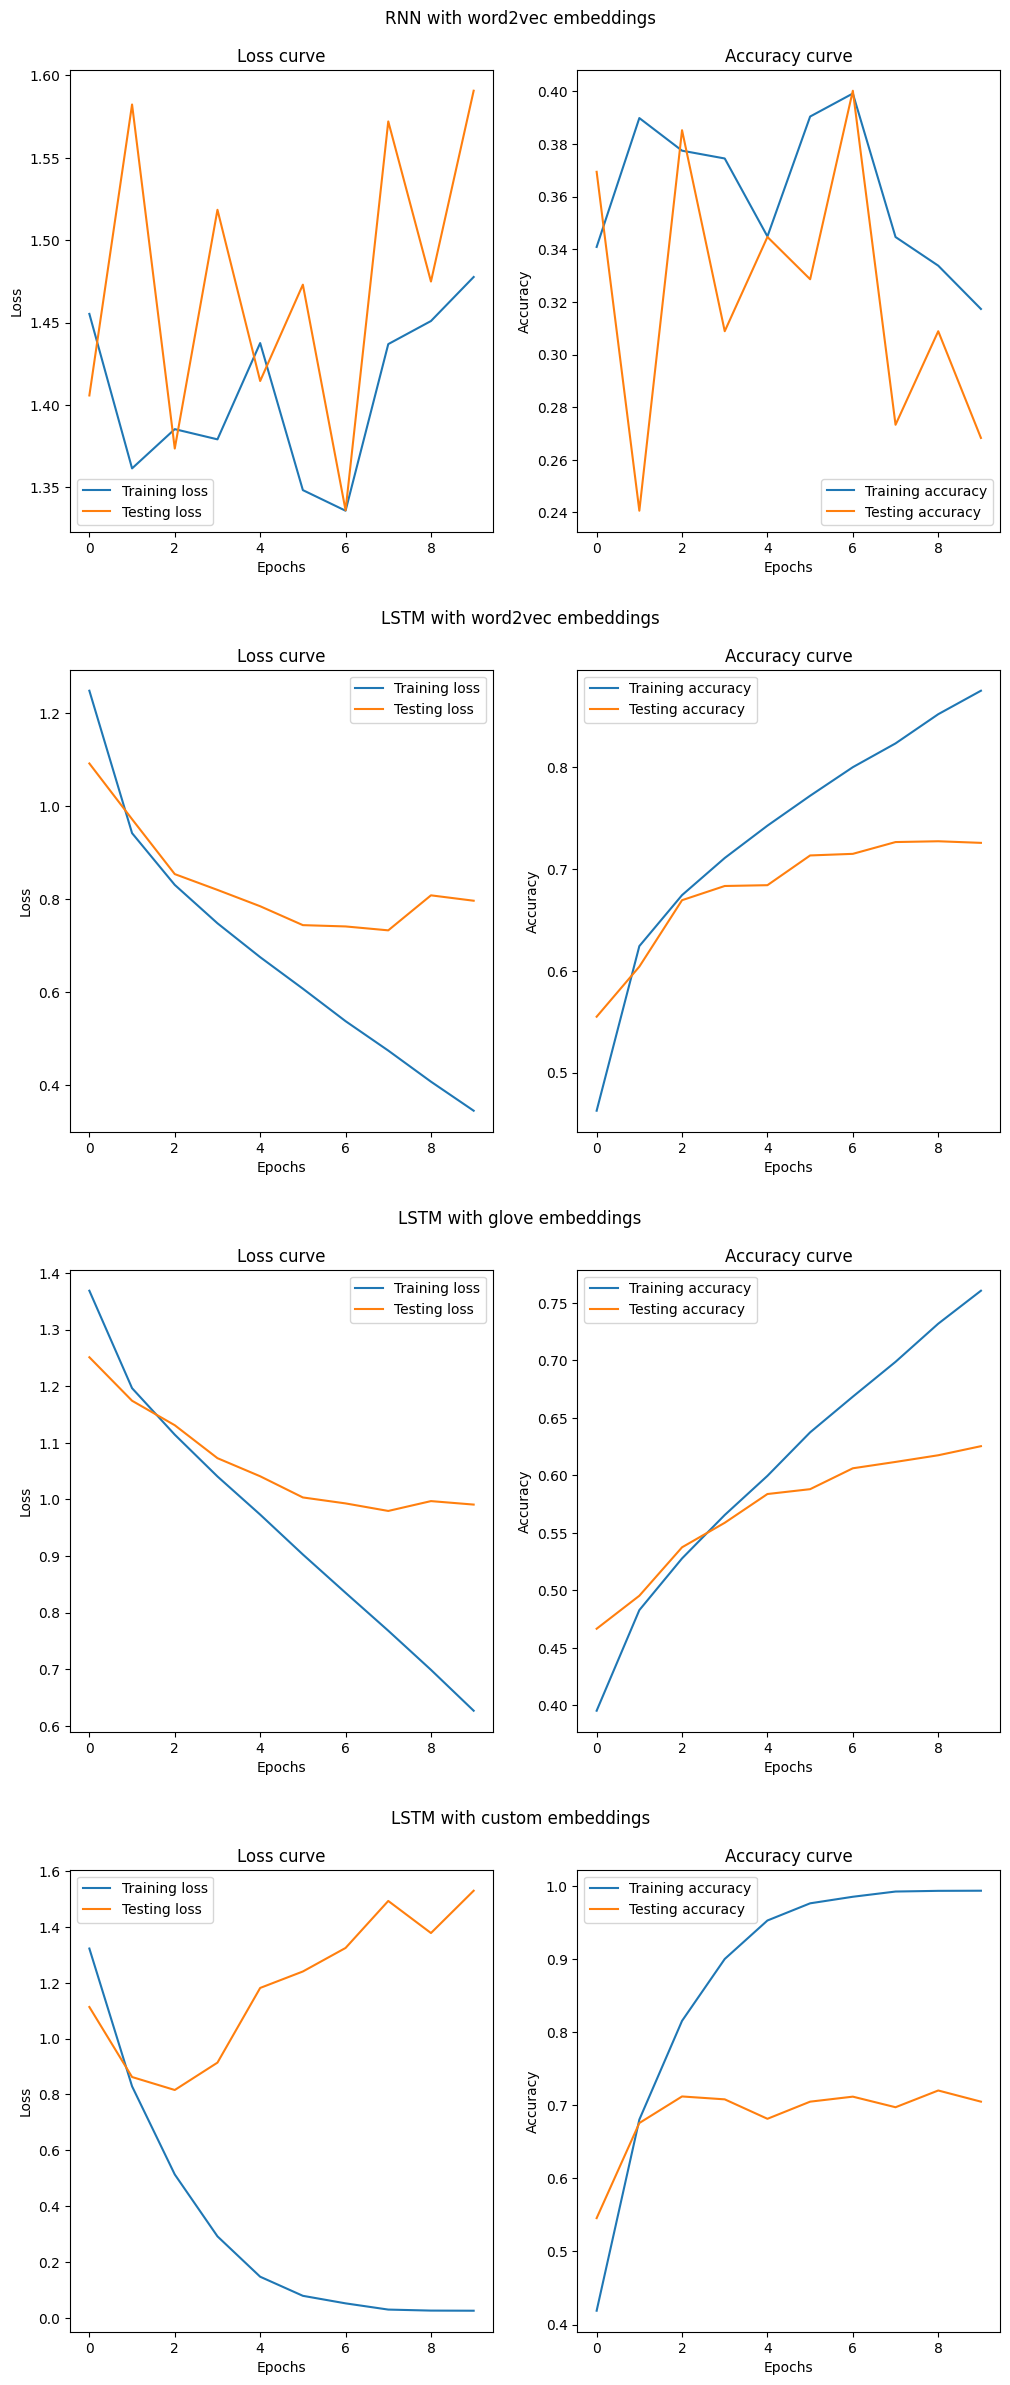

In [16]:
rows = len(models)
fig = plt.figure(figsize=(12, rows * 6))
subfigs = fig.subfigures(4, 1)
axes = np.array([subfigs[i].subplots(1, 2) for i in range(rows)])

for i, (model_performance, model_name) in enumerate(zip(model_performances, model_names)):
    subfigs[i].suptitle(model_name)

    axes[i, 0].set_title("Loss curve")
    axes[i, 0].set_xlabel("Epochs")
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].plot(model_performance["train_losses"], label="Training loss")
    axes[i, 0].plot(model_performance["test_losses"], label="Testing loss")
    axes[i, 0].legend()

    axes[i, 1].set_title("Accuracy curve")
    axes[i, 1].set_xlabel("Epochs")
    axes[i, 1].set_ylabel("Accuracy")
    axes[i, 1].plot(model_performance["train_accuracies"], label="Training accuracy")
    axes[i, 1].plot(model_performance["test_accuracies"], label="Testing accuracy")
    axes[i, 1].legend()

plt.show()


In [17]:
column_titles = {
    "MulticlassAccuracy": "Accuracy",
    "MulticlassPrecision": "Macro Precision",
    "MulticlassRecall": "Macro Recall",
    "MulticlassF1Score": "Macro F1-score"
}

print(tabulate(metrics, headers=column_titles, tablefmt="fancy_grid", showindex=model_names, floatfmt=".0%"))

╒═══════════════════════════════╤════════════╤═══════════════════╤════════════════╤══════════════════╕
│                               │   Accuracy │   Macro Precision │   Macro Recall │   Macro F1-score │
╞═══════════════════════════════╪════════════╪═══════════════════╪════════════════╪══════════════════╡
│ RNN with word2vec embeddings  │        27% │               11% │            21% │              14% │
├───────────────────────────────┼────────────┼───────────────────┼────────────────┼──────────────────┤
│ LSTM with word2vec embeddings │        73% │               75% │            73% │              74% │
├───────────────────────────────┼────────────┼───────────────────┼────────────────┼──────────────────┤
│ LSTM with glove embeddings    │        63% │               65% │            63% │              64% │
├───────────────────────────────┼────────────┼───────────────────┼────────────────┼──────────────────┤
│ LSTM with custom embeddings   │        70% │               73% │       

### Conclusions

The LSTM trained using word2vec embeddings performed slightly better than the LSTM trained using GloVe embeddings, likely because the word2vec embeddings have higher dimensions. All three LSTMs, particularly the one trained using custom embeddings, had higher training accuracy than testing accuracy, which suggests they overfit to the training data. The LSTM greatly outperformed the RNN in all experiments.